# Compendio de ejemplos — Dynamic Augmented Pooled Testing

Un ejemplo clave de cada notebook del proyecto, contado con su figura y un par de
frases. La grafica manda; el texto solo la enmarca. Todo sale de correr el codigo
del paquete `augmented`.


In [1]:
%matplotlib inline
import os, sys
_d = os.path.abspath(os.getcwd())
while _d != os.path.dirname(_d) and not os.path.isfile(os.path.join(_d, "augmented", "__init__.py")):
    _d = os.path.dirname(_d)
if not os.path.isfile(os.path.join(_d, "augmented", "__init__.py")):
    _fb = "/Users/hectorbecerrilvillamil/Desktop/PooledTesting/pooled-testing-dynamic"
    if os.path.isfile(os.path.join(_fb, "augmented", "__init__.py")):
        _d = _fb
if _d not in sys.path:
    sys.path.insert(0, _d)
import numpy as np
import matplotlib.pyplot as plt
import random
random.seed(0); np.random.seed(0)


## Deduccion cruzada: cuando dos tests comparten gente

Dos pools comparten al agente 1. El Test A sobre {0,1} cuenta exactamente 1 infectado y el Test B sobre {1,2} cuenta 0. Como B limpia al agente 1, la cuenta de A obliga a que el agente 0 este infectado con certeza. El posterior conjunto (counting y Gibbs) recupera esa deduccion; el update secuencial, que mira un test a la vez, se queda en 0.50 porque el agente 0 no aparece en el Test B.

/var/folders/zn/lnx_6ksj0r1b93bw0d12m0mm0000gn/T/ipykernel_60060/2001211275.py:61: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 1, 0.95])


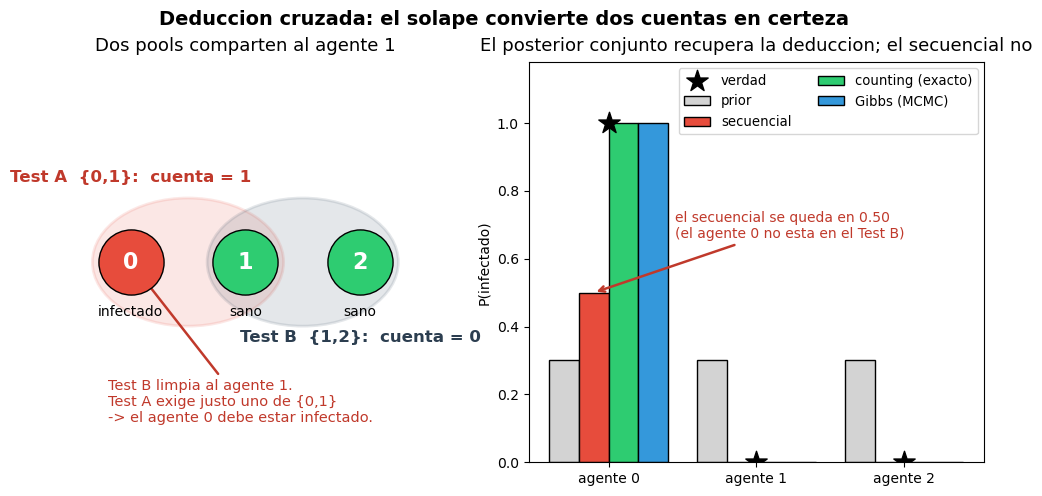

In [2]:
from augmented.core import mask_from_indices
from augmented.bayesian import bayesian_update, bayesian_update_by_counting, gibbs_update
from matplotlib.patches import Ellipse

# --- Instancia de deduccion cruzada: dos pools que comparten al agente 1 ---
n = 3
p = [0.3, 0.3, 0.3]                       # prior: cada uno 30%
history = (
    (mask_from_indices([0, 1]), 1),       # Test A sobre {0,1}: cuenta = 1
    (mask_from_indices([1, 2]), 0),       # Test B sobre {1,2}: cuenta = 0
)

seq = bayesian_update(p, history, n)              # por-test, se pierde el solape
cnt = bayesian_update_by_counting(p, history, n)  # posterior conjunto exacto
gbs = gibbs_update(p, history, n, num_iterations=2000, seed=42)
correct = [1.0, 0.0, 0.0]

fig = plt.figure(figsize=(12, 5.2))
gs = fig.add_gridspec(1, 2, width_ratios=[1.05, 1.25], wspace=0.22)

# ---------- IZQUIERDA: diagrama de pools ----------
axL = fig.add_subplot(gs[0]); axL.set_xlim(0, 10); axL.set_ylim(0, 10); axL.axis('off')
axL.set_title("Dos pools comparten al agente 1", fontsize=13, pad=8)

pos = {0: (2.0, 5.0), 1: (5.0, 5.0), 2: (8.0, 5.0)}
axL.add_patch(Ellipse((3.5, 5.0), 5.0, 3.2, fill=True,
                      facecolor="#e74c3c", alpha=0.13, edgecolor="#e74c3c", lw=2))
axL.add_patch(Ellipse((6.5, 5.0), 5.0, 3.2, fill=True,
                      facecolor="#34495e", alpha=0.13, edgecolor="#34495e", lw=2))
axL.text(2.0, 7.0, "Test A  {0,1}:  cuenta = 1", color="#c0392b", fontsize=12, ha="center", weight="bold")
axL.text(8.0, 3.0, "Test B  {1,2}:  cuenta = 0", color="#2c3e50", fontsize=12, ha="center", weight="bold")

deduced = {0: "infectado", 1: "sano", 2: "sano"}
colmap = {"infectado": "#e74c3c", "sano": "#2ecc71"}
for i, (x, y) in pos.items():
    axL.scatter([x], [y], s=2200, c=colmap[deduced[i]], edgecolors="black", zorder=5)
    axL.text(x, y, str(i), fontsize=16, ha="center", va="center", color="white", weight="bold", zorder=6)
    axL.text(x, y - 1.25, deduced[i], fontsize=10, ha="center", va="center", zorder=6)

axL.annotate("Test B limpia al agente 1.\nTest A exige justo uno de {0,1}\n-> el agente 0 debe estar infectado.",
             xy=(2.0, 5.0), xytext=(1.4, 1.0), fontsize=10.5, color="#c0392b",
             ha="left", arrowprops=dict(arrowstyle="->", color="#c0392b", lw=1.8))

# ---------- DERECHA: barras de posterior ----------
axR = fig.add_subplot(gs[1])
x = np.arange(n); w = 0.2
axR.bar(x - 1.5*w, p,   w, label="prior",            color="lightgray", edgecolor="black")
axR.bar(x - 0.5*w, seq, w, label="secuencial",       color="#e74c3c",   edgecolor="black")
axR.bar(x + 0.5*w, cnt, w, label="counting (exacto)", color="#2ecc71",  edgecolor="black")
axR.bar(x + 1.5*w, gbs, w, label="Gibbs (MCMC)",     color="#3498db",   edgecolor="black")
axR.scatter(x, correct, marker="*", s=260, color="black", zorder=6, label="verdad")
axR.set_xticks(x); axR.set_xticklabels([f"agente {i}" for i in range(n)])
axR.set_ylabel("P(infectado)"); axR.set_ylim(0, 1.18)
axR.set_title("El posterior conjunto recupera la deduccion; el secuencial no", fontsize=13, pad=8)
axR.legend(ncol=2, fontsize=9.5, loc="upper right")
axR.annotate(f"el secuencial se queda en {seq[0]:.2f}\n(el agente 0 no esta en el Test B)",
             xy=(0 - 0.5*w, seq[0]), xytext=(0.45, 0.66), fontsize=10, color="#c0392b",
             arrowprops=dict(arrowstyle="->", color="#c0392b", lw=1.8))

fig.suptitle("Deduccion cruzada: el solape convierte dos cuentas en certeza", fontsize=14, weight="bold")
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

## Aumentado contra clasico: lo que aporta el conteo exacto

Este notebook replica la estructura empirica de la tesis de Lopez sobre el caso aumentado, donde cada test devuelve el numero exacto de infectados del pool. Sobre las mismas instancias y restricciones (n=5, B=3, G=5), las estrategias se ordenan en una jerarquia que va de no agrupar (U_single) hasta la cota optima (U_max). El punto central: el optimo dinamico aumentado U_DA supera al dinamico clasico U_D, aqui en un 3.2 por ciento de bienestar promedio y en cerca del 98 por ciento de las instancias.

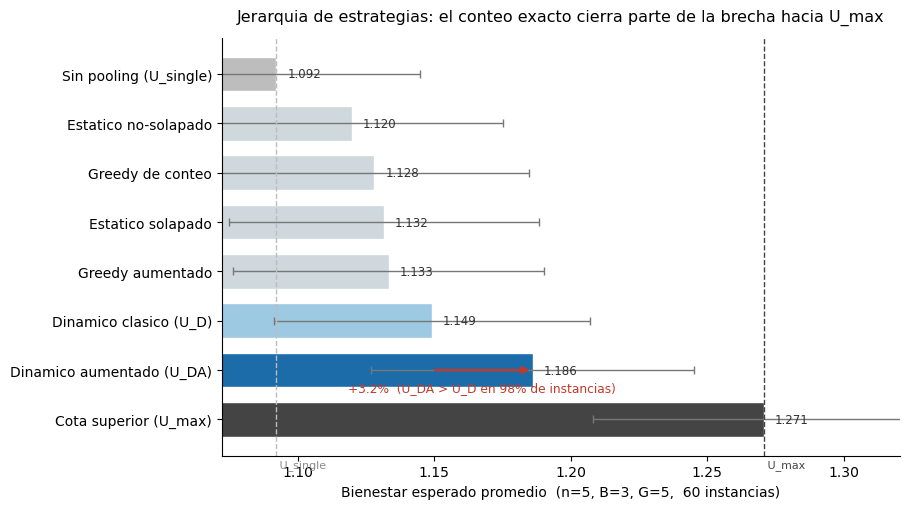

In [3]:
from augmented.baselines import u_single, u_max
from augmented.static_solver import solve_static_non_overlapping, solve_static_overlapping
from augmented.classical_solver import solve_classical_dynamic
from augmented.solver import solve_optimal_dapts
from augmented.greedy import greedy_myopic_expected_utility, greedy_myopic_counting_expected_utility

def _sample(n, rng):
    health = [rng.random() for _ in range(n)]
    p = [1.0 - q for q in health]
    u = [rng.random() for _ in range(n)]
    return p, u

n, B, G, N = 5, 3, 5, 60
rng = random.Random(20250604)
strategies = {
    'Sin pooling (U_single)':    lambda p, u: u_single(p, u, B)[0],
    'Estatico no-solapado':      lambda p, u: solve_static_non_overlapping(p, u, B, G)[0],
    'Estatico solapado':         lambda p, u: solve_static_overlapping(p, u, B, G)[0],
    'Greedy aumentado':          lambda p, u: greedy_myopic_expected_utility(p, u, B, G),
    'Greedy de conteo':          lambda p, u: greedy_myopic_counting_expected_utility(p, u, B, G),
    'Dinamico clasico (U_D)':    lambda p, u: solve_classical_dynamic(p, u, B, G)[0],
    'Dinamico aumentado (U_DA)': lambda p, u: solve_optimal_dapts(p, u, B, G)[0],
    'Cota superior (U_max)':     lambda p, u: u_max(p, u),
}
acc = {k: [] for k in strategies}
for _ in range(N):
    p, u = _sample(n, rng)
    for k, f in strategies.items():
        acc[k].append(f(p, u))

means = {k: float(np.mean(v)) for k, v in acc.items()}
ses   = {k: float(np.std(v, ddof=1) / np.sqrt(N)) for k, v in acc.items()}

aug = np.array(acc['Dinamico aumentado (U_DA)'])
cla = np.array(acc['Dinamico clasico (U_D)'])
frac_better = float((aug > cla + 1e-10).mean())
pct_gap = 100.0 * float((aug - cla).mean()) / float(cla.mean())

order = sorted(means, key=lambda k: means[k])
vals  = [means[k] for k in order]
errs  = [ses[k] for k in order]
lo, hi = means['Sin pooling (U_single)'], means['Cota superior (U_max)']

def _color(k):
    return {'Dinamico aumentado (U_DA)': '#1b6ca8',
            'Dinamico clasico (U_D)': '#9ec9e2',
            'Cota superior (U_max)': '#444444',
            'Sin pooling (U_single)': '#bdbdbd'}.get(k, '#cfd8dc')

fig, ax = plt.subplots(figsize=(9.2, 5.2))
ypos = np.arange(len(order))
ax.barh(ypos, vals, xerr=errs, color=[_color(k) for k in order], edgecolor='white',
        height=0.7, error_kw=dict(ecolor='#777', lw=1, capsize=3))
ax.set_yticks(ypos); ax.set_yticklabels(order, fontsize=10)
ax.set_xlabel('Bienestar esperado promedio  (n=5, B=3, G=5,  %d instancias)' % N, fontsize=10)
ax.set_title('Jerarquia de estrategias: el conteo exacto cierra parte de la brecha hacia U_max',
             fontsize=11.5, pad=12)
ax.axvline(lo, color='#bdbdbd', ls='--', lw=1)
ax.axvline(hi, color='#444444', ls='--', lw=1)
for k in order:
    ax.text(means[k] + 0.004, order.index(k), f'{means[k]:.3f}', va='center', fontsize=8.5, color='#333')

ida = order.index('Dinamico aumentado (U_DA)')
xa, xd = means['Dinamico aumentado (U_DA)'], means['Dinamico clasico (U_D)']
ax.annotate('', xy=(xa, ida), xytext=(xd, ida),
            arrowprops=dict(arrowstyle='-|>', color='#c0392b', lw=1.8))
ax.text((xa + xd) / 2, ida + 0.42,
        f'+{pct_gap:.1f}%  (U_DA > U_D en {frac_better*100:.0f}% de instancias)',
        ha='center', fontsize=8.8, color='#c0392b')

ax.set_xlim(lo - 0.02, hi + 0.05)
ax.invert_yaxis()
for s in ['top', 'right']:
    ax.spines[s].set_visible(False)
ax.text(lo, len(order) - 0.2, ' U_single', color='#8a8a8a', fontsize=8, va='top')
ax.text(hi, len(order) - 0.2, ' U_max', color='#444', fontsize=8, va='top')
plt.tight_layout()
plt.show()

## Dos Mundos: a quien probar cuando unos valen mas

Poblacion de n=8 partida en 4 VIP (rojo, u=10, p=0.3) y 4 comunes (gris, u=1, p=0.1), con B=3 pruebas y pool maximo G=3. El arbol de decision optimo invierte sus tres pruebas exclusivamente en los VIP y nunca toca a los comunes; greedy mete a un comun en el primer pool y deja un 10% de utilidad sobre la mesa.

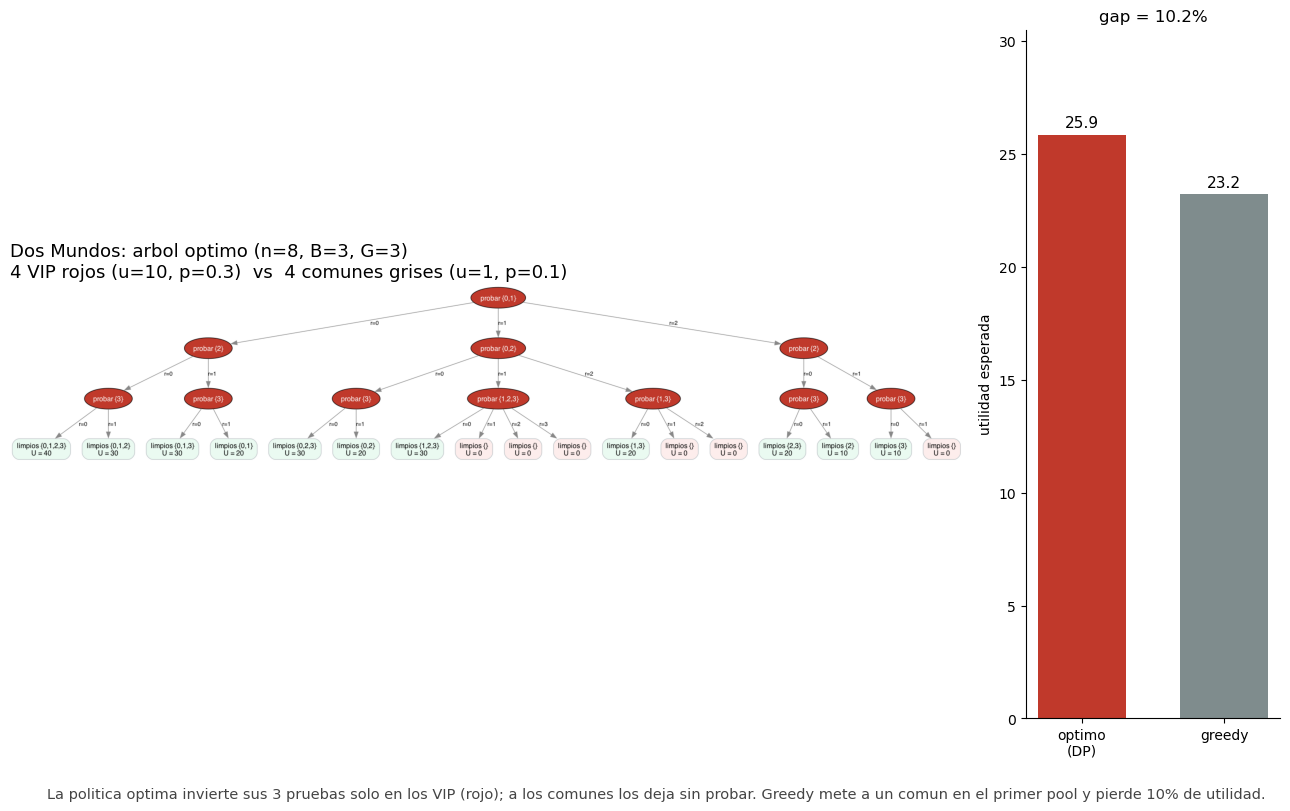

In [4]:
# --- CARTA: large_trees_exploration -- "Dos Mundos" (VIP vs comun) ---
# Arbol de decision optimo para n=8 = 4 VIP (u=10,p=0.3) + 4 comunes (u=1,p=0.1),
# B=3, G=3. La politica optima gasta TODO el presupuesto en los VIP; greedy se desvia.
# (asume setup: sys.path con ROOT, np, plt, random ya importados)
import io
import graphviz
from PIL import Image as PILImage
from augmented.solver import solve_optimal_dapts
from augmented.tree_extractor import extract_tree
from augmented.hybrid_solver import hybrid_greedy_bruteforce

n, B, G = 8, 3, 3
p = [0.3]*4 + [0.1]*4          # VIP (0-3) vs comun (4-7)
u = [10.0]*4 + [1.0]*4

val_opt, pol_opt = solve_optimal_dapts(p, u, B, G)
tree         = extract_tree(pol_opt, p, u, n)
tree_greedy, eu_greedy = hybrid_greedy_bruteforce(p, u, B, G, greedy_steps=B)
gap_pct = (val_opt - eu_greedy) / val_opt * 100

# --- arbol de decision con graphviz ---
g = graphviz.Digraph('two_worlds', format='png')
g.attr(rankdir='TB', bgcolor='white', nodesep='0.28', ranksep='0.55')
g.attr('node', fontname='Helvetica', fontsize='12')
g.attr('edge', fontname='Helvetica', fontsize='10', color='#888888')
VIP, COM = '#c0392b', '#7f8c8d'

ctr = [0]
def add(node, parent=None, elabel=None):
    nid = f'nd{ctr[0]}'; ctr[0] += 1
    if node.get('terminal'):
        util = node.get('utility', 0.0)
        cleared = node.get('cleared_str', '{}')
        col = '#eafaf1' if util > 0 else '#fdedec'
        g.node(nid, f'limpios {cleared}\\nU = {util:.0f}', shape='box',
               style='rounded,filled', fillcolor=col, color='#bdc3c7')
    else:
        pool = node.get('pool_str', '{}')
        idxs = [int(x) for x in pool.strip('{}').split(',') if x != '']
        only_vip = all(i < 4 for i in idxs)
        g.node(nid, f'probar {pool}', shape='ellipse',
               style='filled', fillcolor=(VIP if only_vip else COM), fontcolor='white')
    if parent is not None:
        g.edge(parent, nid, label=elabel)
    if not node.get('terminal'):
        for r, ch in sorted(node.get('children', {}).items()):
            add(ch, nid, f'r={r}')
    return nid

add(tree)
tree_img = PILImage.open(io.BytesIO(g.pipe(format='png')))

# --- arbol + barra de EU ---
fig = plt.figure(figsize=(13, 8.2))
gs = fig.add_gridspec(1, 20, wspace=0.0)
ax_tree = fig.add_subplot(gs[0, 0:15]); ax_bar = fig.add_subplot(gs[0, 16:20])

ax_tree.imshow(tree_img); ax_tree.axis('off')
ax_tree.set_title(
    'Dos Mundos: arbol optimo (n=8, B=3, G=3)\n'
    '4 VIP rojos (u=10, p=0.3)  vs  4 comunes grises (u=1, p=0.1)',
    fontsize=13, loc='left')

bars = ax_bar.bar(['optimo\n(DP)', 'greedy'], [val_opt, eu_greedy],
                  color=[VIP, COM], width=0.62)
ax_bar.bar_label(bars, fmt='%.1f', padding=3, fontsize=11)
ax_bar.set_ylabel('utilidad esperada'); ax_bar.set_ylim(0, val_opt*1.18)
ax_bar.set_title(f'gap = {gap_pct:.1f}%', fontsize=12)
ax_bar.spines[['top', 'right']].set_visible(False)

fig.text(0.04, 0.02,
    'La politica optima invierte sus 3 pruebas solo en los VIP (rojo); a los comunes '
    f'los deja sin probar. Greedy mete a un comun en el primer pool y pierde {gap_pct:.0f}% de utilidad.',
    fontsize=10.5, color='#444444')
plt.tight_layout(rect=[0, 0.05, 1, 1])
plt.show()

## La heuristica de independencia y su error

El scoring greedy aproxima la PMF del conteo del pool como producto de marginales (Poisson-Binomial). Cuando un test previo deja `0 < r' < |t'|`, esa aproximacion falla: aqui el caso limpio con prior `p=0.5`, historial `t'={0,1}` con `r'=1` y pool `t={0,1,2,3}`. La heuristica pone masa `0.0625` en `r_t=0` cuando la exacta es 0 (el pool no puede quedar limpio), con distancia de variacion total `0.125`.

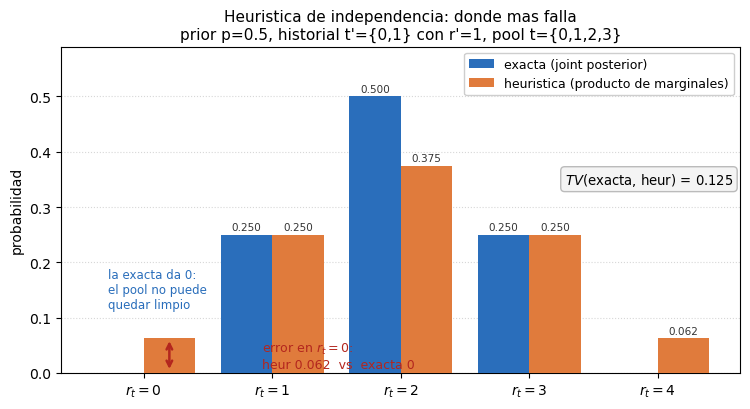

In [5]:
from augmented.core import mask_from_indices
from augmented.independence_gap import exact_pool_pmf, independence_pool_pmf, tv_distance

# Ejemplo 1: 4 personas, prior simetrico p=0.5.
# Historial: probamos t'={0,1} y salio r'=1 (exactamente uno infectado).
# Puntuamos el pool grande t={0,1,2,3}: PMF exacta vs heuristica de independencia.
n = 4
p = [0.5] * n
history = ((mask_from_indices([0, 1]), 1),)
pool = mask_from_indices([0, 1, 2, 3])

exact = exact_pool_pmf(p, history, pool, n)
heur  = independence_pool_pmf(p, history, pool, n)
tv = tv_distance(exact, heur)

x = np.arange(n + 1)
w = 0.40
fig, ax = plt.subplots(figsize=(7.6, 4.2))
b1 = ax.bar(x - w/2, exact, w, label='exacta (joint posterior)', color='#2a6ebb', zorder=3)
b2 = ax.bar(x + w/2, heur,  w, label='heuristica (producto de marginales)',
            color='#e07b3c', zorder=3)

# Marca el error en r=0: la heuristica pone masa donde la exacta es 0.
ax.annotate('', xy=(0 + w/2, heur[0]), xytext=(0 + w/2, 0.002),
            arrowprops=dict(arrowstyle='<->', color='#b3261e', lw=1.8))
ax.text(0.92, heur[0] / 2,
        f'error en $r_t{{=}}0$:\nheur {heur[0]:.3f}  vs  exacta 0',
        color='#b3261e', fontsize=9, va='center', ha='left')
ax.text(-0.28, heur[0] + 0.05, 'la exacta da 0:\nel pool no puede\nquedar limpio',
        color='#2a6ebb', fontsize=8.5, va='bottom', ha='left')

for b in list(b1) + list(b2):
    h = b.get_height()
    # Etiqueta valores, salvo la barra naranja en r=0 (ya marcada en rojo).
    if h > 0.004 and not (abs(b.get_x() + b.get_width()/2 - w/2) < 1e-6):
        ax.text(b.get_x() + b.get_width()/2, h + 0.004, f'{h:.3f}',
                ha='center', va='bottom', fontsize=7.5, color='#333')

ax.set_xticks(x)
ax.set_xticklabels([f'$r_t={k}$' for k in range(n + 1)])
ax.set_ylabel('probabilidad')
ax.set_ylim(0, max(max(exact), max(heur)) * 1.18)
ax.set_title('Heuristica de independencia: donde mas falla\n'
             "prior p=0.5, historial t'={0,1} con r'=1, pool t={0,1,2,3}",
             fontsize=11)
ax.legend(loc='upper right', fontsize=9, framealpha=0.95)
ax.grid(True, axis='y', linestyle=':', alpha=0.5, zorder=0)
ax.text(0.99, 0.62, f'$TV$(exacta, heur) = {tv:.3f}',
        transform=ax.transAxes, ha='right', va='top', fontsize=9.5,
        bbox=dict(boxstyle='round', fc='#f4f4f4', ec='#bbb'))
plt.tight_layout()
plt.show()

## VW super-nodos: cuando el producto de marginales miente

VW comprime el posterior conjunto en marginales independientes. El scatter compara la verdad conjunta contra esa aproximación de producto sobre los 63 subconjuntos de una instancia n=6 con dos tests positivos. Los puntos rojos son los pools que ya contienen un test positivo observado: su verdad es exactamente 1 (sabemos que hay un infectado ahí), pero el producto la subestima hasta en 0.28.

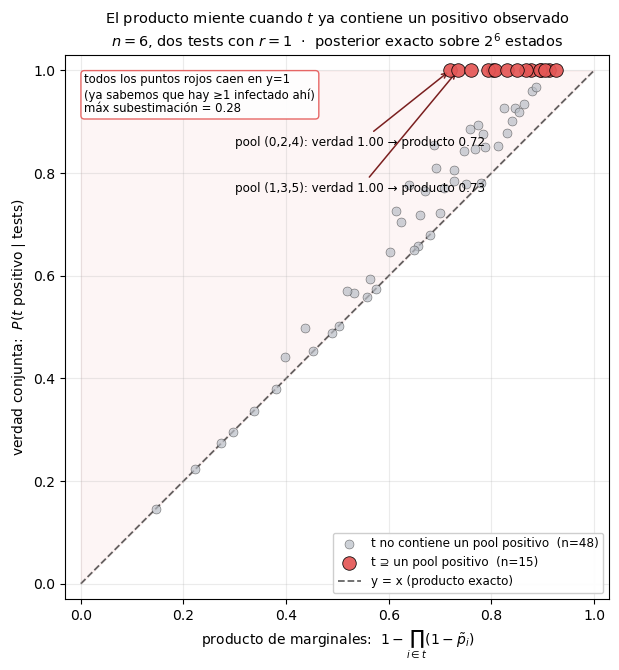

In [6]:
import math, itertools as itt
from IPython.display import display

# --- Posterior conjunto exacto sobre las 2^6 configuraciones de Z ---
n = 6
p_prior = [0.10, 0.15, 0.20, 0.08, 0.12, 0.25]

def joint_posterior(n, p_prior, tests):
    raw = {}
    for Z in range(1 << n):
        w = 1.0
        for i in range(n):
            w *= p_prior[i] if (Z >> i) & 1 else (1.0 - p_prior[i])
        for pool_idx, r_obs in tests:                      # test determinista dado Z
            if sum(1 for i in pool_idx if (Z >> i) & 1) != r_obs:
                w = 0.0; break
        raw[Z] = w
    Zt = sum(raw.values())
    return {k: v / Zt for k, v in raw.items()}

def marginals(joint):    return [sum(p for Z, p in joint.items() if (Z >> i) & 1) for i in range(n)]
def true_pos(joint, t):  m = sum(1 << i for i in t); return sum(p for Z, p in joint.items() if (Z & m) != 0)

tests = [((0, 2, 4), 1), ((1, 3, 5), 1)]   # dos pools, ambos con r=1 infectado
joint = joint_posterior(n, p_prior, tests)
p_til = marginals(joint)                   # los tilde_p que usaria VW

rows = []
for size in range(1, n + 1):
    for t in itt.combinations(range(n), size):
        rows.append((t, size, true_pos(joint, t), 1 - math.prod(1 - p_til[i] for i in t)))

positive_pools = [set(p) for p, r in tests if r >= 1]
def has_pos(t): return any(set(t) >= p for p in positive_pools)
yes = [r for r in rows if has_pos(r[0])]   # t contiene un pool positivo -> verdad = 1
no  = [r for r in rows if not has_pos(r[0])]

# --- Scatter: verdad conjunta vs producto de marginales ---
fig, ax = plt.subplots(figsize=(7.4, 6.8))
xs, ys = zip(*[(r[3], r[2]) for r in no])
ax.scatter(xs, ys, c='#B9BEC6', s=42, alpha=0.7, edgecolor='black', linewidth=0.3,
           label=f't no contiene un pool positivo  (n={len(no)})', zorder=2)
xs, ys = zip(*[(r[3], r[2]) for r in yes])
ax.scatter(xs, ys, c='#E45756', s=95, alpha=0.92, edgecolor='black', linewidth=0.6,
           label=f't ⊇ un pool positivo  (n={len(yes)})', zorder=4)
ax.plot([0, 1], [0, 1], 'k--', alpha=0.6, lw=1.3, label='y = x (producto exacto)', zorder=1)
ax.fill_between([0, 1], [0, 1], [1, 1], color='#E45756', alpha=0.06, zorder=0)

r1 = next(rr for rr in rows if rr[0] == (0, 2, 4))
r2 = next(rr for rr in rows if rr[0] == (1, 3, 5))
ax.annotate(f"pool (0,2,4): verdad 1.00 → producto {r1[3]:.2f}",
            xy=(r1[3], r1[2]), xytext=(0.30, 0.86), fontsize=8.6, ha='left', va='center',
            arrowprops=dict(arrowstyle='->', color='#7a1f1f', lw=1.1))
ax.annotate(f"pool (1,3,5): verdad 1.00 → producto {r2[3]:.2f}",
            xy=(r2[3], r2[2]), xytext=(0.30, 0.77), fontsize=8.6, ha='left', va='center',
            arrowprops=dict(arrowstyle='->', color='#7a1f1f', lw=1.1))

ax.set_xlim(-0.03, 1.03); ax.set_ylim(-0.03, 1.03); ax.set_aspect('equal')
ax.set_xlabel(r"producto de marginales:  $1-\prod_{i\in t}(1-\tilde p_i)$", fontsize=10)
ax.set_ylabel(r"verdad conjunta:  $P(t\ \mathrm{positivo}\mid\mathrm{tests})$", fontsize=10)
ax.set_title("El producto miente cuando $t$ ya contiene un positivo observado\n"
             "$n=6$, dos tests con $r=1$  ·  posterior exacto sobre $2^6$ estados", fontsize=10.5)
ax.legend(loc='lower right', fontsize=8.6, framealpha=0.95)
ax.grid(alpha=0.25, zorder=0)

errs = np.array([r[2] - r[3] for r in rows])
ax.text(0.035, 0.965,
        f"todos los puntos rojos caen en y=1\n(ya sabemos que hay ≥1 infectado ahí)\n"
        f"máx subestimación = {errs.max():.2f}",
        transform=ax.transAxes, fontsize=8.4, va='top',
        bbox=dict(boxstyle='round', fc='white', ec='#E45756', alpha=0.9))

fig.tight_layout(); plt.show()

## La pared del DP exacto

Resolver el problema de forma exacta recorre los $2^n$ perfiles de infección, así que el tiempo se multiplica por un factor casi constante (~3.7) con cada individuo extra. El solver lo medimos hasta $n=10$ y extrapolamos hacia su cota dura $n=14$: ahí ya son ~10 minutos por instancia, y por eso hace falta un greedy.

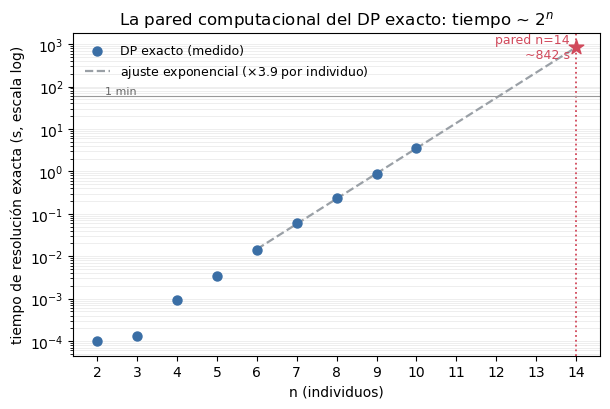

tiempo medido n=10: 3.55 s
tiempo extrapolado n=14: 842 s (~14.0 min)


In [7]:
import time
from augmented import solver
from augmented.solver import solve_optimal_dapts

MAX_N = solver._MAX_N  # cota dura del solver exacto (= 14)

# Medimos el DP exacto (fuerza bruta) hasta n=10; mas alla tarda demasiado.
ns = list(range(2, 11))
times = []
for nn in ns:
    pp = [min(0.10 + 0.03 * i, 0.9) for i in range(nn)]
    uu = [1.0 + i for i in range(nn)]
    t0 = time.time()
    solve_optimal_dapts(pp, uu, 2, 3)
    times.append(time.time() - t0)

# Ajuste exponencial sobre el regimen ya explotado (n >= 6) y pared en n=14.
fit_n = np.array([nn for nn in ns if nn >= 6], dtype=float)
fit_t = np.log(np.array([t for nn, t in zip(ns, times) if nn >= 6]))
a, b = np.polyfit(fit_n, fit_t, 1)
ext_n = np.arange(6, MAX_N + 1)
ext_t = np.exp(a * ext_n + b)
factor = np.exp(a)                       # multiplicador de tiempo por cada +1 en n
t_wall = float(np.exp(a * MAX_N + b))    # tiempo extrapolado en la pared

fig, ax = plt.subplots(figsize=(6.2, 4.2))
ax.scatter(ns, np.maximum(times, 1e-4), s=42, color='#3a6ea5',
           zorder=3, label='DP exacto (medido)')
ax.plot(ext_n, ext_t, '--', color='#9aa0a6', lw=1.6,
        label=fr'ajuste exponencial ($\times${factor:.1f} por individuo)')
ax.scatter([MAX_N], [t_wall], s=120, marker='*', color='#d1495b', zorder=4)
ax.axvline(MAX_N, color='#d1495b', lw=1.3, ls=':')
ax.text(MAX_N - 0.15, t_wall, f'  pared n={MAX_N}\n  ~{t_wall:,.0f} s',
        color='#d1495b', va='center', ha='right', fontsize=9)
ax.axhline(60, color='0.6', lw=0.8)
ax.text(2.2, 60, '1 min', color='0.4', va='bottom', fontsize=8)

ax.set_yscale('log')
ax.set_xticks(range(2, MAX_N + 1))
ax.set_xlabel('n (individuos)')
ax.set_ylabel('tiempo de resolución exacta (s, escala log)')
ax.set_title('La pared computacional del DP exacto: tiempo ~ 2$^n$')
ax.legend(frameon=False, loc='upper left', fontsize=9)
ax.grid(True, which='both', axis='y', color='0.92', lw=0.6)
plt.tight_layout()
plt.show()

print(f'tiempo medido n=10: {times[-1]:.2f} s')
print(f'tiempo extrapolado n=14: {t_wall:,.0f} s (~{t_wall/60:.1f} min)')

## El conteo exacto rinde mas cuando hay mas tests

El test augmented devuelve el conteo exacto de infectados; el clasico solo dice positivo o negativo. Con un solo test (B=1) ambos coinciden, pero al crecer el presupuesto la ventaja del conteo se ensancha de forma monotona: con B>=3 el optimo augmented supera al clasico en las 20 instancias. Mas tests significan mas estados que el conteo puede distinguir.

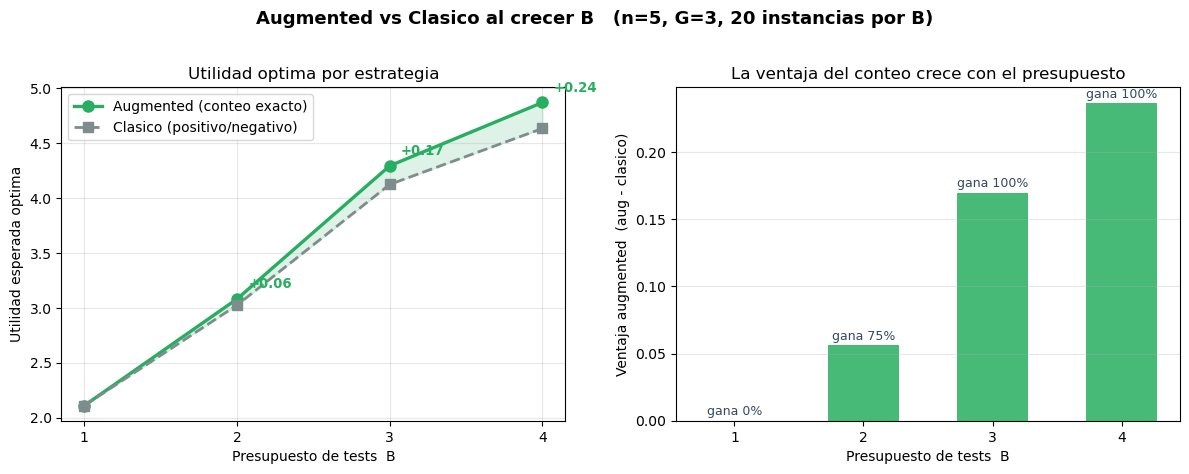

In [8]:
# --- Compendio: ventaja augmented vs clasico al crecer el presupuesto B ---
# (n=5, G=3; promedio sobre instancias aleatorias por cada valor de B)
from augmented.solver import solve_optimal_dapts
from augmented.classical_solver import solve_classical_dynamic

np.random.seed(42)
n, G, N_INST = 5, 3, 20
B_range = [1, 2, 3, 4]

aug_mean, cls_mean, adv_mean, winrate = [], [], [], []
for B in B_range:
    aug, cls = [], []
    for _ in range(N_INST):
        p_inst = np.random.uniform(0.1, 0.9, size=n).tolist()
        u_inst = [float(np.random.choice([1, 2, 3])) for _ in range(n)]
        va, _ = solve_optimal_dapts(p_inst, u_inst, B, G)        # conteo exacto
        vc, _ = solve_classical_dynamic(p_inst, u_inst, B, G)    # positivo/negativo
        aug.append(va); cls.append(vc)
    aug_mean.append(np.mean(aug)); cls_mean.append(np.mean(cls))
    adv_mean.append(np.mean([a - c for a, c in zip(aug, cls)]))
    winrate.append(np.mean([a > c for a, c in zip(aug, cls)]) * 100)

C_AUG, C_CLS = '#27ae60', '#7f8c8d'
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.6))
x = np.array(B_range)

# Izquierda: utilidad optima de cada estrategia
ax1.plot(x, aug_mean, 'o-', color=C_AUG, lw=2.4, ms=8, label='Augmented (conteo exacto)')
ax1.plot(x, cls_mean, 's--', color=C_CLS, lw=2.0, ms=7, label='Clasico (positivo/negativo)')
ax1.fill_between(x, cls_mean, aug_mean, color=C_AUG, alpha=0.15)
for xi, a, c in zip(x, aug_mean, cls_mean):
    if a - c > 0.01:
        ax1.annotate(f'+{a - c:.2f}', (xi, a), textcoords='offset points',
                     xytext=(8, 8), fontsize=9.5, color=C_AUG,
                     ha='left', fontweight='bold')
ax1.set_xlabel('Presupuesto de tests  B'); ax1.set_ylabel('Utilidad esperada optima')
ax1.set_title('Utilidad optima por estrategia')
ax1.set_xticks(x); ax1.legend(loc='upper left', fontsize=10); ax1.grid(alpha=0.3)

# Derecha: la ventaja (aug - clasico) y la tasa de victorias
ax2.bar(x, adv_mean, color=C_AUG, alpha=0.85, width=0.55)
ax2.set_xlabel('Presupuesto de tests  B')
ax2.set_ylabel('Ventaja augmented  (aug - clasico)')
ax2.set_title('La ventaja del conteo crece con el presupuesto')
ax2.set_xticks(x); ax2.grid(axis='y', alpha=0.3)
for xi, adv, wr in zip(x, adv_mean, winrate):
    ax2.annotate(f'gana {wr:.0f}%', (xi, adv), textcoords='offset points',
                 xytext=(0, 4), ha='center', fontsize=9, color='#34495e')

fig.suptitle(f'Augmented vs Clasico al crecer B   (n={n}, G={G}, {N_INST} instancias por B)',
             fontsize=13, fontweight='bold', y=1.02)
fig.tight_layout()
plt.show()

## Gibbs validado contra el posterior exacto

El hallazgo central de Phase 3 fue corregir el muestreador de Gibbs: con pools que se solapan, el sampler ingenuo quedaba atrapado en una sola componente del conjunto factible y devolvia posteriors degenerados (error hasta 0.70 frente al exacto). Tras el arreglo (enumeracion exacta para conjuntos chicos y saltos de bloque MH) las marginales coinciden con la enumeracion exacta. Las barras verdes caen justo encima de las grises.

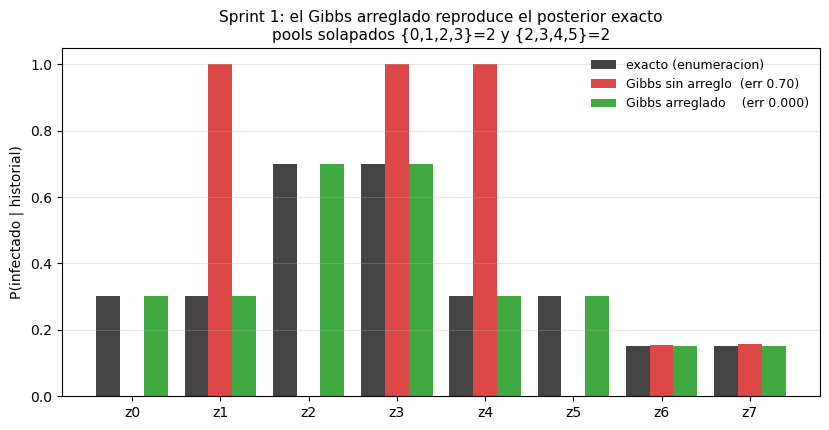

Gibbs sin arreglo: error maximo 0.698 (posterior degenerado).
Gibbs arreglado:   error maximo 0.0000 (coincide con el exacto).


In [9]:
from augmented.bayesian import bayesian_update_by_counting, gibbs_update
from augmented.core import mask_from_indices

def _bits(mask, n):
    return [(mask >> i) & 1 for i in range(n)]

# Single-site Gibbs SIN los arreglos: mezcla local que se atasca en una
# sola componente del conjunto factible cuando los pools comparten individuos.
def naive_single_site_gibbs(p, history, n, num_iterations=3000, burn_in=500, seed=0):
    rng = random.Random(seed)
    pools = [(_bits(m, n), r) for m, r in history]
    def feasible(x):
        for pb, r in pools:
            if sum(x[i] for i in range(n) if pb[i]) != r:
                return False
        return True
    x = None
    for _ in range(20000):
        cand = [1 if rng.random() < p[i] else 0 for i in range(n)]
        if feasible(cand):
            x = cand; break
    counts = [0.0] * n; nsamp = 0
    for it in range(num_iterations):
        for i in range(n):
            x2 = x[:]; x2[i] ^= 1
            if feasible(x2):
                pi = p[i]
                a = (pi / (1 - pi)) if x2[i] == 1 else ((1 - pi) / pi)
                if rng.random() < min(1.0, a):
                    x = x2
        if it >= burn_in:
            for i in range(n):
                counts[i] += x[i]
            nsamp += 1
    return [c / nsamp for c in counts]

# Instancia con DOS pools que comparten individuos (2 y 3): el caso que rompia el sampler.
n = 8
p = [0.15] * n
history = ((mask_from_indices([0, 1, 2, 3]), 2),
           (mask_from_indices([2, 3, 4, 5]), 2))

exact = bayesian_update_by_counting(p, history, n)               # O(2^n), referencia
naive = naive_single_site_gibbs(p, history, n, seed=1)           # Gibbs antes del arreglo
fixed = gibbs_update(p, history, n, num_iterations=3000, seed=1)  # Gibbs actual

err_naive = max(abs(naive[i] - exact[i]) for i in range(n))
err_fixed = max(abs(fixed[i] - exact[i]) for i in range(n))

idx = np.arange(n)
w = 0.27
fig, ax = plt.subplots(figsize=(8.4, 4.4))
ax.bar(idx - w, exact, w, label="exacto (enumeracion)", color="#444444")
ax.bar(idx,     naive, w, label=f"Gibbs sin arreglo  (err {err_naive:.2f})", color="#d62728", alpha=0.85)
ax.bar(idx + w, fixed, w, label=f"Gibbs arreglado    (err {err_fixed:.3f})", color="#2ca02c", alpha=0.9)

ax.set_xticks(idx)
ax.set_xticklabels([f"z{i}" for i in range(n)])
ax.set_ylabel("P(infectado | historial)")
ax.set_ylim(0, 1.05)
ax.set_title("Sprint 1: el Gibbs arreglado reproduce el posterior exacto\n"
             "pools solapados {0,1,2,3}=2 y {2,3,4,5}=2", fontsize=11)
ax.legend(frameon=False, fontsize=9, loc="upper right")
ax.grid(True, axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Gibbs sin arreglo: error maximo {err_naive:.3f} (posterior degenerado).")
print(f"Gibbs arreglado:   error maximo {err_fixed:.4f} (coincide con el exacto).")